In [2]:
from pathlib import Path
import sys

# ------------------------------------------------------------------
# Locate the project root and add it to PYTHONPATH
# ------------------------------------------------------------------

project_root = Path.cwd()

while project_root.name != "EventCameraProject":
    if project_root.parent == project_root:
        raise RuntimeError("Could not locate EventCameraProject root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)

# ------------------------------------------------------------------
# Imports
# ------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from src.data.evimo2.parser import EVIMO2Parser
from src.preprocessing.object_motion import (
    collect_world_trajectories,
    compute_camera_path_length,
)

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True

Project root: /home/ayon/git/EventCameraProject


In [3]:
sequence_path = Path(
    "/home/ayon/HDD/EventDatasets/EVIMO2_official/"
    "left_camera/imo/train/"
    "scene13_dyn_test_01_000000"
)

assert sequence_path.exists()
sequence_path

PosixPath('/home/ayon/HDD/EventDatasets/EVIMO2_official/left_camera/imo/train/scene13_dyn_test_01_000000')

In [4]:
dataset = EVIMO2Parser(sequence_path)

sequence = dataset.sequence
frames = dataset.frames

print("Sequence :", sequence.sequence_name)
print("Frames   :", len(frames))
print("Objects  :", len(sequence.objects))
print("Events   :", f"{sequence.num_events:,}")

Sequence : scene13_dyn_test_01_000000
Frames   : 404
Objects  : 8
Events   : 38,328,869


In [5]:
camera_positions = []

for frame in frames:

    if frame.camera_pose is None:
        continue

    camera_positions.append(
        frame.camera_pose.translation
    )

camera_positions = np.asarray(camera_positions)

print("Tracked camera poses :", len(camera_positions))

print(
    "Camera path length :",
    compute_camera_path_length(frames),
    "m"
)

Tracked camera poses : 392
Camera path length : 1.881612777709961 m


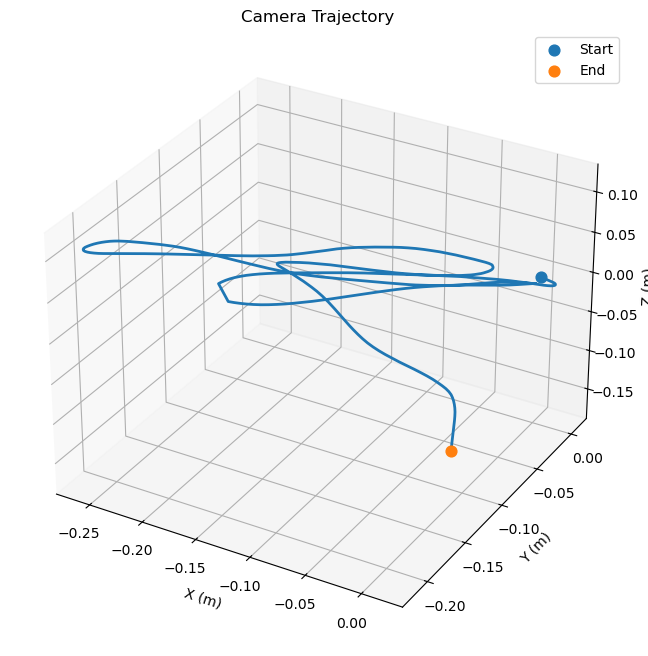

In [6]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection="3d")

ax.plot(
    camera_positions[:, 0],
    camera_positions[:, 1],
    camera_positions[:, 2],
    linewidth=2,
)

ax.scatter(
    camera_positions[0, 0],
    camera_positions[0, 1],
    camera_positions[0, 2],
    s=60,
    label="Start",
)

ax.scatter(
    camera_positions[-1, 0],
    camera_positions[-1, 1],
    camera_positions[-1, 2],
    s=60,
    label="End",
)

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")

ax.set_title("Camera Trajectory")

ax.legend()

plt.show()

In [7]:
trajectories = collect_world_trajectories(
    frames=frames,
    objects=sequence.objects,
)

print(f"Computed trajectories for {len(trajectories)} objects.")

Computed trajectories for 8 objects.


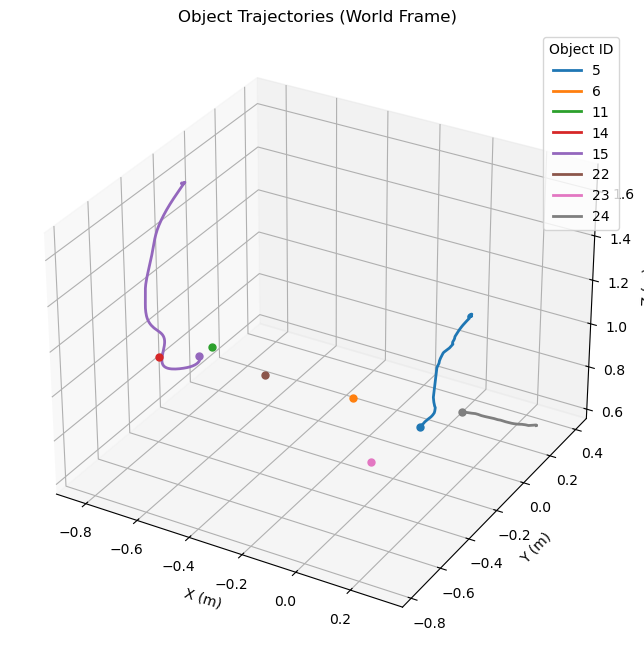

In [8]:
fig = plt.figure(figsize=(9, 8))

ax = fig.add_subplot(111, projection="3d")

for object_id, trajectory in sorted(trajectories.items()):

    positions = trajectory.positions

    ax.plot(
        positions[:, 0],
        positions[:, 1],
        positions[:, 2],
        label=f"{object_id}",
        linewidth=2,
    )

    ax.scatter(
        positions[0, 0],
        positions[0, 1],
        positions[0, 2],
        s=25,
    )

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")

ax.set_title("Object Trajectories (World Frame)")

ax.legend(title="Object ID")

plt.show()

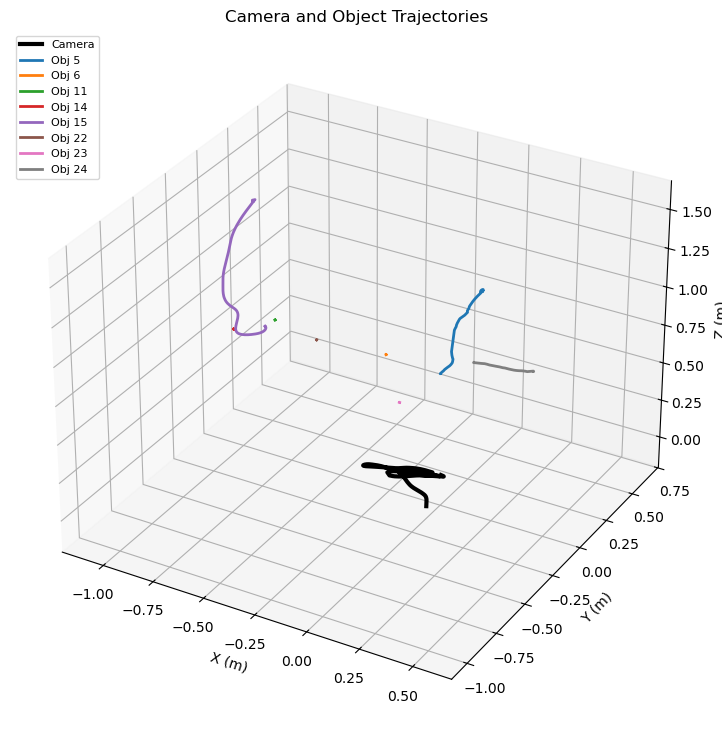

In [10]:
def set_axes_equal(ax):
    """
    Make x, y and z axes use the same scale.

    This prevents distortion of 3D trajectories.
    """

    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    radius = 0.5 * max(x_range, y_range, z_range)

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    ax.set_xlim3d([x_middle - radius, x_middle + radius])
    ax.set_ylim3d([y_middle - radius, y_middle + radius])
    ax.set_zlim3d([z_middle - radius, z_middle + radius])
fig = plt.figure(figsize=(10, 9))

ax = fig.add_subplot(111, projection="3d")

# Camera
ax.plot(
    camera_positions[:, 0],
    camera_positions[:, 1],
    camera_positions[:, 2],
    color="black",
    linewidth=3,
    label="Camera",
)

# Objects
for object_id, trajectory in sorted(trajectories.items()):

    p = trajectory.positions

    ax.plot(
        p[:, 0],
        p[:, 1],
        p[:, 2],
        linewidth=2,
        label=f"Obj {object_id}",
    )

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")

ax.set_title("Camera and Object Trajectories")

ax.legend(
    fontsize=8,
    loc="upper left",
)

set_axes_equal(ax)

plt.show()